<a href="https://colab.research.google.com/github/Diviyah13/Deep_learning_projects/blob/main/lexicon_based_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TEXT BLOB

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from textblob import TextBlob

In [ ]:
input_text = 'the cake tastes great'

new variable added

In [ ]:
result = TextBlob(input_text)

In [ ]:
result.sentiment.polarity

0.8

EXAMPLE ON ACTUAL DATASET

Import any sentiment analysis data and do modeling using above model.

In [ ]:
!pip install datasets

HuggingFace dataset loading

In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("imdb")

df = dataset['train'].to_pandas()

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


TEXTBLOB

In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

In [ ]:
df_polarity = []

for text in df['text']:
    result = TextBlob(text)

    if result.sentiment.polarity > 0:
        df_polarity.append('positive')
    elif result.sentiment.polarity == 0:
        df_polarity.append('neutral')
    else:
        df_polarity.append('negative')

In [ ]:
df['predicted_textblob'] = df_polarity
df

,text,label,predicted_textblob
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,positive
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,positive
3,This film was probably inspired by Godard's Ma...,0,positive
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [ ]:
df['actual'] = df['label'].map({
    0:'negative',
    1:'positive'
})

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(df['actual'], df['predicted_textblob'])
error = 1 - accuracy

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Error: {error:.2f}")
print(confusion_matrix(df['actual'], df['predicted_textblob']))
print(classification_report(df['actual'], df['predicted_textblob']))

Accuracy: 68.49%
Error: 0.32
[[ 5303     7  7190]
 [    0     0     0]
 [  674     7 11819]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    negative       0.89      0.42      0.57     12500
     neutral       0.00      0.00      0.00         0
    positive       0.62      0.95      0.75     12500

    accuracy                           0.68     25000
   macro avg       0.50      0.46      0.44     25000
weighted avg       0.75      0.68      0.66     25000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


VADER

In [ ]:
!pip install vaderSentiment

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sentiment = SentimentIntensityAnalyzer()

In [ ]:
vader_predictions = []

for text in df['text']:
    score = sentiment.polarity_scores(text)['compound']

    if score >= 0.05:
        vader_predictions.append('positive')
    elif score <= -0.05:
        vader_predictions.append('negative')
    else:
        vader_predictions.append('neutral')

In [ ]:
df['predicted_vader'] = vader_predictions
df

,text,label,predicted_textblob,actual,predicted_vader
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,positive,negative,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative,negative,negative
2,If only to avoid making this type of film in t...,0,positive,negative,positive
3,This film was probably inspired by Godard's Ma...,0,positive,negative,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative,negative,negative
...,...,...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive,positive,positive
24996,I love this movie like no other. Another time ...,1,positive,positive,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive,positive,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive,positive,positive


In [ ]:
accuracy = accuracy_score(df['actual'], df['predicted_vader'])
error = 1 - accuracy

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Error: {error:.2f}")
print(confusion_matrix(df['actual'], df['predicted_vader']))
print(classification_report(df['actual'], df['predicted_vader']))

Accuracy: 69.03%
Error: 0.31
[[ 6556   133  5811]
 [    0     0     0]
 [ 1747    52 10701]]
              precision    recall  f1-score   support

    negative       0.79      0.52      0.63     12500
     neutral       0.00      0.00      0.00         0
    positive       0.65      0.86      0.74     12500

    accuracy                           0.69     25000
   macro avg       0.48      0.46      0.46     25000
weighted avg       0.72      0.69      0.68     25000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Visualization of the sentiment distribution

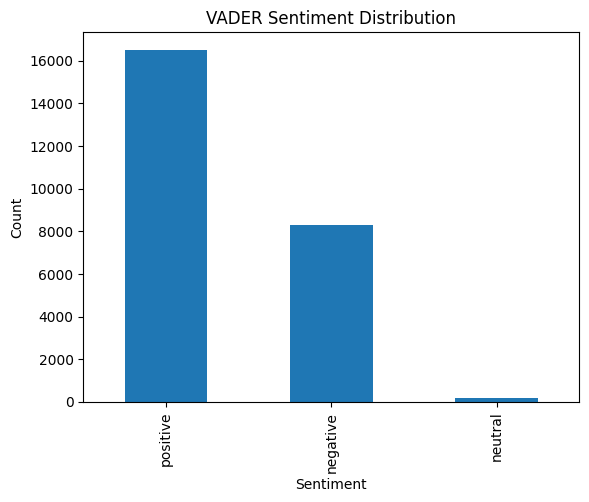

In [ ]:
import matplotlib.pyplot as plt

df['predicted_vader'].value_counts().plot(kind='bar')

plt.title('VADER Sentiment Distribution')

plt.xlabel('Sentiment')

plt.ylabel('Count')

plt.show()

In this exercise, lexicon-based sentiment analysis was applied using TextBlob and VADER on the IMDB movie review dataset. The dataset was imported directly using the HuggingFace datasets library instead of manually downloading files. The text reviews were analyzed using polarity scores and classified into positive, negative, or neutral sentiment categories. The predicted labels were evaluated using accuracy, confusion matrix, and classification report. The results showed that VADER slightly outperformed TextBlob in sentiment prediction accuracy. This shows how lexicon-based NLP techniques can analyze opinions and emotions from textual data without training a machine learning model.